# Proyecto 01 - Obtención y Limpieza de datos

Integrantes:
- José Ricardo Méndez González, 21289
- Sara María Pérez Echeverría, 21371
- Emily Elvia Melissa Pérez Alarcón, 21385
- Adrian Fulladolsa Palma, 21592

Enlace al [Libro de códigos](https://docs.google.com/document/d/1U0nvif0mvgl6dNbNNd6HRSqXl0mCYmDKB-AXi3_cxgc/edit?usp=sharing)

### Librerías

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import math
import seaborn as sns
from collections import defaultdict
from fuzzywuzzy import process, fuzz

C:\Users\sarap\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\fuzzywuzzy\fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


## Sobre el conjunto de datos

In [2]:
dir = "./data"
all_data = []
for filename in os.listdir(dir):
    if filename.endswith('.csv'):
        file_path = os.path.join(dir, filename)
        df = pd.read_csv(file_path, header=1)
        all_data.append(df)
        
df = pd.concat(all_data, ignore_index=True)
df.head(10)

,CODIGO,DISTRITO,DEPARTAMENTO,MUNICIPIO,ESTABLECIMIENTO,DIRECCION,TELEFONO,SUPERVISOR,DIRECTOR,NIVEL,SECTOR,AREA,STATUS,MODALIDAD,JORNADA,PLAN,DEPARTAMENTAL
0,16-01-0138-46,16-031,ALTA VERAPAZ,COBAN,COLEGIO COBAN,KM.2 SALIDA A SAN JUAN CHAMELCO ZONA 8,77945104,MERCEDES JOSEFINA TORRES GALVEZ,GUSTAVO ADOLFO SIERRA POP,DIVERSIFICADO,PRIVADO,URBANA,ABIERTA,MONOLINGUE,MATUTINA,DIARIO(REGULAR),ALTA VERAPAZ
1,16-01-0139-46,16-031,ALTA VERAPAZ,COBAN,COLEGIO PARTICULAR MIXTO VERAPAZ,KM 209.5 ENTRADA A LA CIUDAD,77367402,MERCEDES JOSEFINA TORRES GALVEZ,GILMA DOLORES GUAY PAZ DE LEAL,DIVERSIFICADO,PRIVADO,URBANA,ABIERTA,MONOLINGUE,MATUTINA,DIARIO(REGULAR),ALTA VERAPAZ
2,16-01-0140-46,16-031,ALTA VERAPAZ,COBAN,"COLEGIO ""LA INMACULADA""",7A. AVENIDA 11-109 ZONA 6,78232301,MERCEDES JOSEFINA TORRES GALVEZ,VIRGINIA SOLANO SERRANO,DIVERSIFICADO,PRIVADO,URBANA,ABIERTA,MONOLINGUE,MATUTINA,DIARIO(REGULAR),ALTA VERAPAZ
3,16-01-0141-46,16-005,ALTA VERAPAZ,COBAN,ESCUELA NACIONAL DE CIENCIAS COMERCIALES,2A CALLE 11-10 ZONA 2,79514215,RUDY ADOLFO TOT OCH,H�CTOR ROLANDO CHUN POOU,DIVERSIFICADO,OFICIAL,URBANA,ABIERTA,MONOLINGUE,MATUTINA,DIARIO(REGULAR),ALTA VERAPAZ
4,16-01-0142-46,16-005,ALTA VERAPAZ,COBAN,INSTITUTO NORMAL MIXTO DEL NORTE 'EMILIO ROSAL...,3A AVE 6-23 ZONA 11,79521468,RUDY ADOLFO TOT OCH,VICTOR HUGO DOM�NGUEZ REYES,DIVERSIFICADO,OFICIAL,URBANA,ABIERTA,BILINGUE,VESPERTINA,DIARIO(REGULAR),ALTA VERAPAZ
5,16-01-0143-46,16-031,ALTA VERAPAZ,COBAN,COLEGIO PARTICULAR MIXTO IMPERIAL,5A. CALLE 1-9 ZONA 3,57101061,MERCEDES JOSEFINA TORRES GALVEZ,H�CTOR WALDEMAR TOT COY,DIVERSIFICADO,PRIVADO,URBANA,ABIERTA,MONOLINGUE,DOBLE,FIN DE SEMANA,ALTA VERAPAZ
6,16-01-0145-46,16-006,ALTA VERAPAZ,COBAN,INSTITUTO DE TURSMO Y AVIACON DEL NORTE I.T.A.N,3 AV. 5-28 ZONA 4,54641454,EFRAIN CAAL CUC,LUIS FERNANDO SOTO,DIVERSIFICADO,PRIVADO,URBANA,CERRADA TEMPORALMENTE,MONOLINGUE,MATUTINA,DIARIO(REGULAR),ALTA VERAPAZ
7,16-01-0147-46,16-031,ALTA VERAPAZ,COBAN,"COLEGIO ""LA INMACULADA""",7A. CALLE 11-09 ZONA 6 COBAN,49532425,MERCEDES JOSEFINA TORRES GALVEZ,ROSA MAR�A ZAMORA GONZ�LEZ,DIVERSIFICADO,PRIVADO,RURAL,CERRADA TEMPORALMENTE,MONOLINGUE,DOBLE,DIARIO(REGULAR),ALTA VERAPAZ
8,16-01-0150-46,16-006,ALTA VERAPAZ,COBAN,INSTITUTO INTERCULTRUAL ALTAVERAPACENCESE -IIAV-,3A. AVAENIDA 1-23 ZONA 4,NaN,EFRAIN CAAL CUC,GUILLERMO ESTUARDO VASQUEZ MORALES,DIVERSIFICADO,PRIVADO,URBANA,CERRADA TEMPORALMENTE,BILINGUE,DOBLE,FIN DE SEMANA,ALTA VERAPAZ
9,16-01-0155-46,16-031,ALTA VERAPAZ,COBAN,"LICEO ""MODERNO LATINO""",11 AVENIDA 5-17 ZONA 4,79522555,MERCEDES JOSEFINA TORRES GALVEZ,H�CTOR ARMANDO TEYUL CHEN,DIVERSIFICADO,PRIVADO,URBANA,ABIERTA,MONOLINGUE,DOBLE,FIN DE SEMANA,ALTA VERAPAZ


In [3]:
for column in df.columns:
        print(f"Valores en la columna '{column}':")
        print(df[column].value_counts())
        print("\n" + "-"*40 + "\n")

Valores en la columna 'CODIGO':
00-03-8227-46    2
00-01-9817-46    2
00-01-9790-46    2
00-01-9792-46    2
00-01-9798-46    2
                ..
01-14-9266-46    1
01-14-9261-46    1
01-14-9071-46    1
01-14-9005-46    1
19-11-0018-46    1
Name: CODIGO, Length: 9207, dtype: int64

----------------------------------------

Valores en la columna 'DISTRITO':
01-403    528
11-017    176
01-411    173
05-033    167
01-641    157
         ... 
20-002      1
17-048      1
12-092      1
17-038      1
19-020      1
Name: DISTRITO, Length: 675, dtype: int64

----------------------------------------

Valores en la columna 'DEPARTAMENTO':
CIUDAD CAPITAL    3128
GUATEMALA         1479
ESCUINTLA          628
SAN MARCOS         574
HUEHUETENANGO      516
QUETZALTENANGO     491
SUCHITEPEQUEZ      385
ALTA VERAPAZ       374
IZABAL             368
PETEN              366
CHIMALTENANGO      359
SACATEPEQUEZ       319
RETALHULEU         316
JUTIAPA            310
QUICHE             244
CHIQUIMULA         

In [4]:
nullCount = df.isnull().sum()

print(nullCount)

CODIGO                0
DISTRITO            271
DEPARTAMENTO          0
MUNICIPIO             0
ESTABLECIMIENTO       0
DIRECCION            56
TELEFONO            624
SUPERVISOR          272
DIRECTOR           1158
NIVEL                 0
SECTOR                0
AREA                  0
STATUS                0
MODALIDAD             0
JORNADA               0
PLAN                  0
DEPARTAMENTAL         0
dtype: int64


#### Se ubican de forma sencilla columnas que proveen poca información y se debería considerar removerlas como Codigo, Distrito, Telefono, Supervisor, Director y otras. Además, la mayoría de estas poseen una cantidad significativa de valores nulos.

#### La columna PLAN tiene valores que pueden entorpecer el estudio de estos datos. Lo ideal sería recodificar cada tipo de plan a un texto tipo string identificable.

#### La columna DEPARTAMENTAL tiene valores algo ambiguos. Se propone cambiar a una columna tipo REGION y ubicar cada departamento en una region NORTE, SUR, ESTE Y OESTE del país de Guatemala. Puede perderse información debido a la falta del departamento pero agrupa de mejor manera los datos y puede ser la solución óptima para su estudio.

#### La columna MUNICIPIO contiene valores que pueden entorpecer el estudio, tales como 'ZONA 1', lo cual no provee información real sobre el municipio del individuo. Es posible que deba ser removida para que el estudio no se vea perjudicado por estas incoherencias entre columna-valor.

In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10771 entries, 0 to 10770
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   CODIGO           10771 non-null  object
 1   DISTRITO         10500 non-null  object
 2   DEPARTAMENTO     10771 non-null  object
 3   MUNICIPIO        10771 non-null  object
 4   ESTABLECIMIENTO  10771 non-null  object
 5   DIRECCION        10715 non-null  object
 6   TELEFONO         10147 non-null  object
 7   SUPERVISOR       10499 non-null  object
 8   DIRECTOR         9613 non-null   object
 9   NIVEL            10771 non-null  object
 10  SECTOR           10771 non-null  object
 11  AREA             10771 non-null  object
 12  STATUS           10771 non-null  object
 13  MODALIDAD        10771 non-null  object
 14  JORNADA          10771 non-null  object
 15  PLAN             10771 non-null  object
 16  DEPARTAMENTAL    10771 non-null  object
dtypes: object(17)
memory usage: 1.4

In [6]:
print(df.describe(include='all'))

               CODIGO DISTRITO    DEPARTAMENTO MUNICIPIO  \
count           10771    10500           10771     10771   
unique           9207      675              22       341   
top     00-03-8227-46   01-403  CIUDAD CAPITAL    ZONA 1   
freq                2      528            3128      1266   

                                      ESTABLECIMIENTO           DIRECCION  \
count                                           10771               10715   
unique                                           5266                5948   
top     INSTITUTO NACIONAL DE EDUCACION DIVERSIFICADA  CABECERA MUNICIPAL   
freq                                              325                 266   

        TELEFONO                        SUPERVISOR DIRECTOR          NIVEL  \
count      10147                             10499     9613          10771   
unique      5369                               645     4631              1   
top     22067425  CARLOS HUMBERTO GONZALEZ DE LEON      ---  DIVERSIFICADO   
f

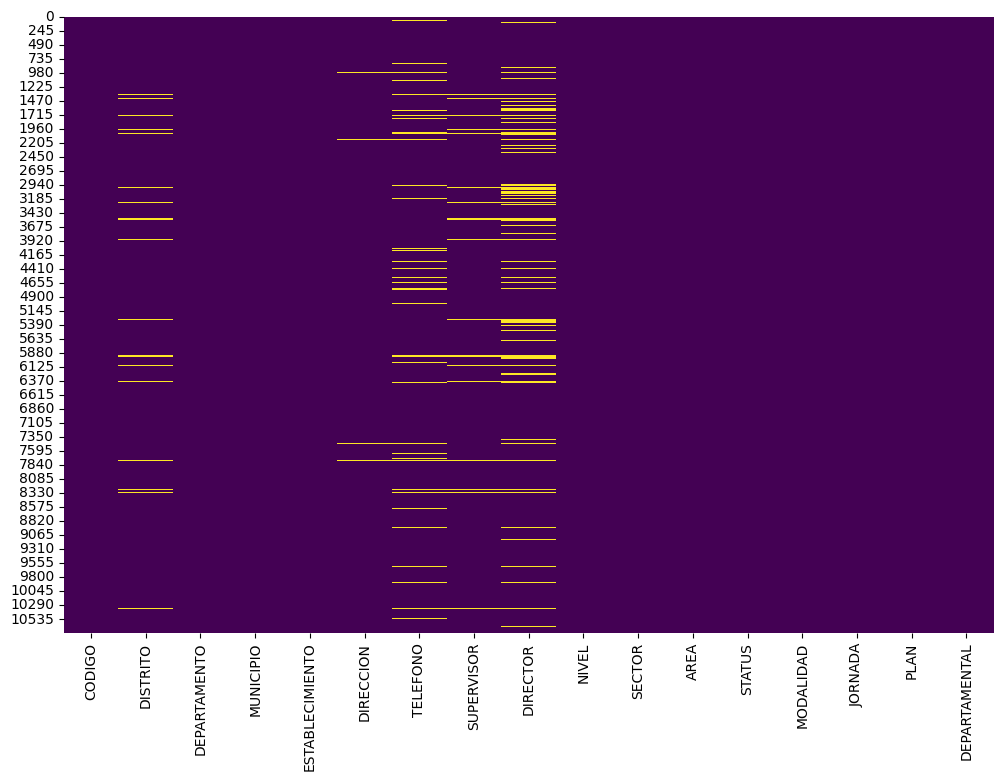

In [7]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=['object']).isnull(), cbar=False, cmap='viridis')
plt.show()

In [8]:
for column in df.select_dtypes(include=['object']).columns:
    print(df[column].value_counts())
    print("\n")

00-03-8227-46    2
00-01-9817-46    2
00-01-9790-46    2
00-01-9792-46    2
00-01-9798-46    2
                ..
01-14-9266-46    1
01-14-9261-46    1
01-14-9071-46    1
01-14-9005-46    1
19-11-0018-46    1
Name: CODIGO, Length: 9207, dtype: int64


01-403    528
11-017    176
01-411    173
05-033    167
01-641    157
         ... 
20-002      1
17-048      1
12-092      1
17-038      1
19-020      1
Name: DISTRITO, Length: 675, dtype: int64


CIUDAD CAPITAL    3128
GUATEMALA         1479
ESCUINTLA          628
SAN MARCOS         574
HUEHUETENANGO      516
QUETZALTENANGO     491
SUCHITEPEQUEZ      385
ALTA VERAPAZ       374
IZABAL             368
PETEN              366
CHIMALTENANGO      359
SACATEPEQUEZ       319
RETALHULEU         316
JUTIAPA            310
QUICHE             244
CHIQUIMULA         170
SANTA ROSA         157
JALAPA             151
SOLOLA             138
BAJA VERAPAZ       114
ZACAPA              94
TOTONICAPAN         90
Name: DEPARTAMENTO, dtype: int64


ZONA 1   

In [9]:
column_summary = df.describe(include='object').transpose()
print(column_summary)

                 count unique                                            top  \
CODIGO           10771   9207                                  00-03-8227-46   
DISTRITO         10500    675                                         01-403   
DEPARTAMENTO     10771     22                                 CIUDAD CAPITAL   
MUNICIPIO        10771    341                                         ZONA 1   
ESTABLECIMIENTO  10771   5266  INSTITUTO NACIONAL DE EDUCACION DIVERSIFICADA   
DIRECCION        10715   5948                             CABECERA MUNICIPAL   
TELEFONO         10147   5369                                       22067425   
SUPERVISOR       10499    645               CARLOS HUMBERTO GONZALEZ DE LEON   
DIRECTOR          9613   4631                                            ---   
NIVEL            10771      1                                  DIVERSIFICADO   
SECTOR           10771      4                                        PRIVADO   
AREA             10771      3           

In [10]:
grouped_df = df.groupby('DEPARTAMENTO')['DEPARTAMENTAL'].value_counts().unstack().fillna(0)
print(grouped_df)

DEPARTAMENTAL   ALTA VERAPAZ  BAJA VERAPAZ  CHIMALTENANGO  CHIQUIMULA  \
DEPARTAMENTO                                                            
ALTA VERAPAZ           374.0           0.0            0.0         0.0   
BAJA VERAPAZ             0.0         114.0            0.0         0.0   
CHIMALTENANGO            0.0           0.0          359.0         0.0   
CHIQUIMULA               0.0           0.0            0.0       170.0   
CIUDAD CAPITAL           0.0           0.0            0.0         0.0   
ESCUINTLA                0.0           0.0            0.0         0.0   
GUATEMALA                0.0           0.0            0.0         0.0   
HUEHUETENANGO            0.0           0.0            0.0         0.0   
IZABAL                   0.0           0.0            0.0         0.0   
JALAPA                   0.0           0.0            0.0         0.0   
JUTIAPA                  0.0           0.0            0.0         0.0   
PETEN                    0.0           0.0         

## Limpieza de datos

In [11]:
# 1. Manejo de duplicados en la columna CODIGO
df_cleaned = df.copy()

# Conservación de la primera ocurrencia
df_cleaned = df_cleaned.drop_duplicates(subset=['CODIGO'], keep='first')

In [12]:
# 2. Unificación de ESTABLECIMIENTO
import re

institutions = df['ESTABLECIMIENTO'].unique()

with open('report.txt', 'w', encoding='utf-8') as file:
    for institution in institutions:
        if re.search(r'[�]', institution):
            file.write(f"{institution}\n")
        

In [13]:
# 3. Unificación y limpieza de la columna PLAN

# Unificación de valores
plan_mapping = {
    'DIARIO(REGULAR)': 'REGULAR',
    'FIN DE SEMANA': 'FIN DE SEMANA',
    'SEMIPRESENCIAL (FIN DE SEMANA)': 'SEMIPRESENCIAL',
    'SEMIPRESENCIAL (UN DÍA A LA SEMANA)': 'SEMIPRESENCIAL',
    'SEMIPRESENCIAL (UN D�A A LA SEMANA)': 'SEMIPRESENCIAL',
    'A DISTANCIA': 'A DISTANCIA',
    'VIRTUAL A DISTANCIA': 'VIRTUAL A DISTANCIA',
    'SABATINO': 'SABATINO',
    'SEMIPRESENCIAL (DOS DÍAS A LA SEMANA)': 'SEMIPRESENCIAL',
    'SEMIPRESENCIAL (DOS D�AS A LA SEMANA)': 'SEMIPRESENCIAL',
    'DOMINICAL': 'DOMINICAL',
    'MIXTO': 'MIXTO',
    'IRREGULAR': 'IRREGULAR',
    'INTERCALADO': 'INTERCALADO'
}
df_cleaned['PLAN'] = df_cleaned['PLAN'].map(plan_mapping).fillna(df_cleaned['PLAN'])

In [14]:
# 4. Conversión de la columna DEPARTAMENTO a REGION

region_mapping = {
    'GUATEMALA': 'METROPOLITANA',
    'CIUDAD CAPITAL': 'METROPOLITANA',
    
    'BAJA VERAPAZ': 'NORTE',
    'ALTA VERAPAZ': 'NORTE',
    
    'EL PROGRESO': 'NORORIENTE',
    'IZABAL': 'NORORIENTE',
    'ZACAPA': 'NORORIENTE',
    'CHIQUIMULA': 'NORORIENTE',
    
    'SANTA ROSA': 'SURORIENTE',
    'JALAPA': 'SURORIENTE',
    'JUTIAPA': 'SURORIENTE',
    
    'SACATEPEQUEZ': 'CENTRAL',
    'CHIMALTENANGO': 'CENTRAL',
    'ESCUINTLA': 'CENTRAL',
    
    'SOLOLA': 'SUROCCIDENTE',
    'TOTONICAPAN': 'SUROCCIDENTE',
    'QUETZALTENANGO': 'SUROCCIDENTE',
    'SUCHITEPEQUEZ': 'SUROCCIDENTE',
    'RETALHULEU': 'SUROCCIDENTE',
    'SAN MARCOS': 'SUROCCIDENTE',
    
    'HUEHUETENANGO': 'NOROCCIDENTE',
    'QUICHE': 'NOROCCIDENTE',
    
    'PETEN': 'PETEN',
}

df_cleaned['REGION'] = df_cleaned['DEPARTAMENTO'].map(region_mapping).fillna('DESCONOCIDA')

In [15]:
# 5. Municipio
df_cleaned = df_cleaned[~df_cleaned['MUNICIPIO'].str.contains('ZONA', na=False)]

In [16]:
# 6. Eliminación de columnas innecesarias
columns_to_drop = ['DISTRITO', 'TELEFONO', 'SUPERVISOR', 'DIRECTOR', 'DEPARTAMENTAL']
df_cleaned = df_cleaned.drop(columns=columns_to_drop)

In [17]:
df_cleaned.head()

,CODIGO,DEPARTAMENTO,MUNICIPIO,ESTABLECIMIENTO,DIRECCION,NIVEL,SECTOR,AREA,STATUS,MODALIDAD,JORNADA,PLAN,REGION
0,16-01-0138-46,ALTA VERAPAZ,COBAN,COLEGIO COBAN,KM.2 SALIDA A SAN JUAN CHAMELCO ZONA 8,DIVERSIFICADO,PRIVADO,URBANA,ABIERTA,MONOLINGUE,MATUTINA,REGULAR,NORTE
1,16-01-0139-46,ALTA VERAPAZ,COBAN,COLEGIO PARTICULAR MIXTO VERAPAZ,KM 209.5 ENTRADA A LA CIUDAD,DIVERSIFICADO,PRIVADO,URBANA,ABIERTA,MONOLINGUE,MATUTINA,REGULAR,NORTE
2,16-01-0140-46,ALTA VERAPAZ,COBAN,"COLEGIO ""LA INMACULADA""",7A. AVENIDA 11-109 ZONA 6,DIVERSIFICADO,PRIVADO,URBANA,ABIERTA,MONOLINGUE,MATUTINA,REGULAR,NORTE
3,16-01-0141-46,ALTA VERAPAZ,COBAN,ESCUELA NACIONAL DE CIENCIAS COMERCIALES,2A CALLE 11-10 ZONA 2,DIVERSIFICADO,OFICIAL,URBANA,ABIERTA,MONOLINGUE,MATUTINA,REGULAR,NORTE
4,16-01-0142-46,ALTA VERAPAZ,COBAN,INSTITUTO NORMAL MIXTO DEL NORTE 'EMILIO ROSAL...,3A AVE 6-23 ZONA 11,DIVERSIFICADO,OFICIAL,URBANA,ABIERTA,BILINGUE,VESPERTINA,REGULAR,NORTE


In [19]:
# Save the cleaned dataset in a new CSV file
df_cleaned.to_csv('data/cleanedData.csv', index=False)

In [23]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7643 entries, 0 to 10770
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   CODIGO           7643 non-null   object
 1   DEPARTAMENTO     7643 non-null   object
 2   MUNICIPIO        7643 non-null   object
 3   ESTABLECIMIENTO  7643 non-null   object
 4   DIRECCION        7597 non-null   object
 5   NIVEL            7643 non-null   object
 6   SECTOR           7643 non-null   object
 7   AREA             7643 non-null   object
 8   STATUS           7643 non-null   object
 9   MODALIDAD        7643 non-null   object
 10  JORNADA          7643 non-null   object
 11  PLAN             7643 non-null   object
 12  REGION           7643 non-null   object
dtypes: object(13)
memory usage: 836.0+ KB


In [33]:
df.shape

(10771, 17)

In [24]:
df_cleaned.describe()

,CODIGO,DEPARTAMENTO,MUNICIPIO,ESTABLECIMIENTO,DIRECCION,NIVEL,SECTOR,AREA,STATUS,MODALIDAD,JORNADA,PLAN,REGION
count,7643,7643,7643,7643,7597,7643,7643,7643,7643,7643,7643,7643,7643
unique,7643,21,320,4303,4884,1,4,3,4,2,6,12,8
top,03-01-0052-46,GUATEMALA,MIXCO,INSTITUTO NACIONAL DE EDUCACION DIVERSIFICADA,CABECERA MUNICIPAL,DIVERSIFICADO,PRIVADO,URBANA,ABIERTA,MONOLINGUE,DOBLE,REGULAR,SUROCCIDENTE
freq,1,1479,430,313,266,7643,6416,5948,5539,7355,2579,4665,1994


In [38]:
missing_values = df_cleaned.isnull().sum()
print("Valores nulos por columna:\n", missing_values)

Valores nulos por columna:
 CODIGO              0
DEPARTAMENTO        0
MUNICIPIO           0
ESTABLECIMIENTO     0
DIRECCION          46
NIVEL               0
SECTOR              0
AREA                0
STATUS              0
MODALIDAD           0
JORNADA             0
PLAN                0
REGION              0
dtype: int64


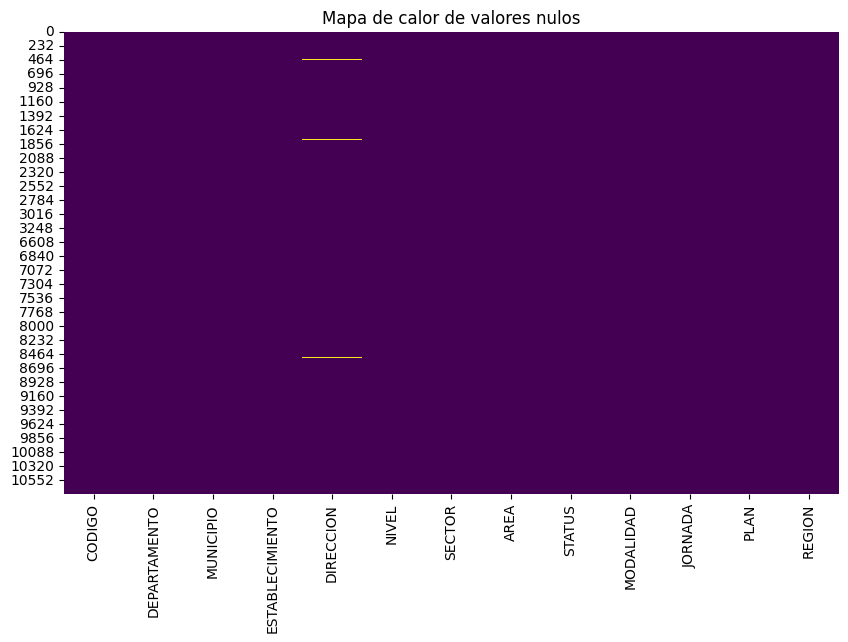

In [46]:
plt.figure(figsize=(10, 6))
sns.heatmap(df_cleaned.isnull(), cbar=False, cmap='viridis')
plt.title("Mapa de calor de valores nulos")
plt.show()

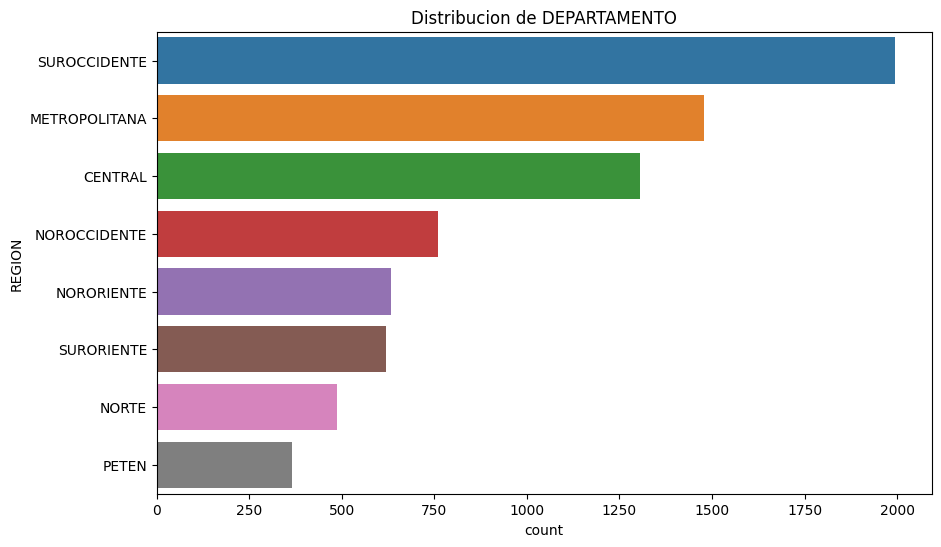

In [45]:
plt.figure(figsize=(10, 6))
sns.countplot(y='REGION', data=df_cleaned, order=df_cleaned['REGION'].value_counts().index)
plt.title('Distribucion de DEPARTAMENTO')
plt.show()

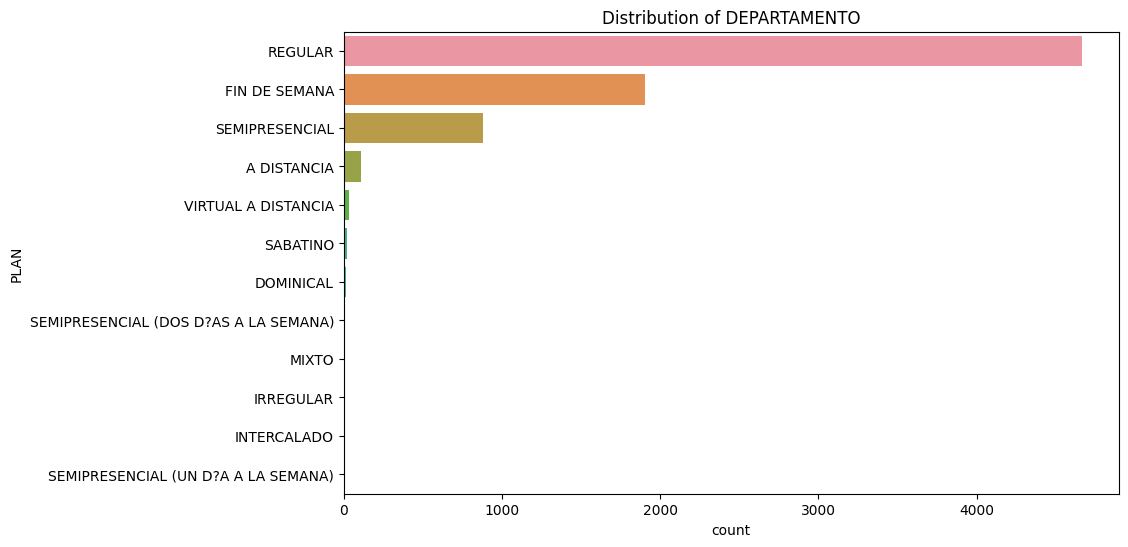

In [41]:
plt.figure(figsize=(10, 6))
sns.countplot(y='PLAN', data=df_cleaned, order=df_cleaned['PLAN'].value_counts().index)
plt.title('Distribucion de PLAN')
plt.show()